In [1]:
import os
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

DATASET_DIR = Path("datasets")

plt.rcParams["figure.figsize"] = (8,4)
plt.rcParams["figure.dpi"] = 120

In [2]:
# ============================================================
# Load Dataset
# ============================================================

with open(DATASET_DIR/"fd_data_s21_adi (1).pickle","rb") as f:
    s21 = pickle.load(f)

with open(DATASET_DIR/"metadata_gen_two.pickle","rb") as f:
    metadata = pd.DataFrame(pickle.load(f))

phantom_db = pd.read_csv(
    DATASET_DIR/"phantom_database.csv"
)

print("Loaded Successfully.")

Loaded Successfully.


In [3]:
# ============================================================
# Dataset Overview
# ============================================================

print("="*60)
print("S21 DATASET")
print("="*60)

print("Type              :",type(s21))
print("Shape             :",s21.shape)
print("Dtype             :",s21.dtype)
print("Complex           :",np.iscomplexobj(s21))
print("Memory            : %.2f MB"%(s21.nbytes/1024**2))

print()

print("Scans             :",s21.shape[0])
print("Frequency Samples :",s21.shape[1])
print("Channels          :",s21.shape[2])

S21 DATASET
Type              : <class 'numpy.ndarray'>
Shape             : (505, 1001, 72)
Dtype             : complex128
Complex           : True
Memory            : 555.36 MB

Scans             : 505
Frequency Samples : 1001
Channels          : 72


In [4]:
# ============================================================
# Metadata Audit
# ============================================================

print("="*60)
print("METADATA")
print("="*60)

print(metadata.shape)

display(metadata.head())

print()

print(metadata.dtypes)

print()

print("Missing Values")

display(metadata.isna().sum())

METADATA
(1301, 22)


,n_expt,id,phant_id,tum_rad,tum_shape,tum_x,tum_y,tum_z,birads,adi_ref_id,...,n_session,ant_rad,ant_z,fib_ang,adi_x,adi_y,fib_ref_id,fib_x,fib_y,tum_in_fib
0,1,1,A11F14,NaN,,NaN,NaN,NaN,4.0,NaN,...,1.0,21.0,-6.51,0.0,0.0,0.0,NaN,0.0,0.0,NaN
1,2,2,A11F14,NaN,,NaN,NaN,NaN,4.0,NaN,...,1.0,21.0,-6.51,15.0,0.0,1.0,NaN,0.0,0.0,NaN
2,3,3,A11F14,NaN,,NaN,NaN,NaN,4.0,NaN,...,1.0,21.0,-6.51,-15.0,0.0,-1.0,NaN,0.0,0.0,NaN
3,4,4,A11F14,NaN,,NaN,NaN,NaN,4.0,NaN,...,1.0,21.0,-6.51,0.0,0.0,0.0,NaN,0.0,-1.0,NaN
4,5,5,A11F14,NaN,,NaN,NaN,NaN,4.0,NaN,...,1.0,21.0,-6.51,0.0,0.5,1.0,NaN,0.0,1.0,NaN



n_expt          int64
id              int64
phant_id       object
tum_rad       float64
tum_shape      object
tum_x         float64
tum_y         float64
tum_z         float64
birads        float64
adi_ref_id    float64
emp_ref_id    float64
date           object
n_session     float64
ant_rad       float64
ant_z         float64
fib_ang       float64
adi_x         float64
adi_y         float64
fib_ref_id    float64
fib_x         float64
fib_y         float64
tum_in_fib    float64
dtype: object

Missing Values


n_expt           0
id               0
phant_id         0
tum_rad        797
tum_shape        0
tum_x          797
tum_y          797
tum_z          797
birads         293
adi_ref_id     795
emp_ref_id     152
date             0
n_session        1
ant_rad          0
ant_z            0
fib_ang        295
adi_x          154
adi_y          154
fib_ref_id    1300
fib_x          292
fib_y          293
tum_in_fib     811
dtype: int64

In [5]:
# ============================================================
# Phantom Database
# ============================================================

print("="*60)
print("PHANTOM DATABASE")
print("="*60)

print(phantom_db.shape)

display(phantom_db.head())

display(phantom_db.describe())

PHANTOM DATABASE
(63, 10)


,phantom_id,shell,density_class,fib_model,shell_volume,breast_length,mean_radius,shell_radius,fib_volume,fib_percent
0,A1F1,A1,C2,F1,294710,77.63,34.6,22.9,12829,0.043531
1,A1F3,A1,C3,F3,294710,77.63,34.6,22.9,58759,0.199379
2,A1F4,A1,C4,F4,294710,77.63,34.6,22.9,108762,0.369048
3,A1F11,A1,C4,F11,294710,77.63,34.6,22.9,80366,0.272695
4,A2F1,A2,C1,F1,729324,115.40,43.8,48.5,12829,0.017590


,shell_volume,breast_length,mean_radius,shell_radius,fib_volume,fib_percent
count,6.300000e+01,63.000000,63.000000,63.000000,63.000000,63.000000
mean,7.815006e+05,109.732063,46.568254,46.985714,101533.888889,0.139063
std,2.500209e+05,17.818396,5.130045,10.048654,69140.586433,0.095720
min,2.947100e+05,77.630000,34.600000,22.900000,12829.000000,0.012402
25%,6.520800e+05,97.000000,43.300000,43.800000,58759.000000,0.054791
50%,7.293240e+05,115.400000,48.200000,48.500000,80366.000000,0.126539
75%,1.031585e+06,123.000000,51.400000,56.550000,148442.000000,0.199506
max,1.113320e+06,138.200000,52.400000,57.000000,275624.000000,0.382462


In [6]:
# ============================================================
# Merge Validation
# ============================================================

metadata = metadata.copy()

metadata["phant_id"] = (
    metadata["phant_id"]
    .fillna("")
    .astype(str)
    .str.strip()
)

merged = metadata.merge(
    phantom_db,
    left_on="phant_id",
    right_on="phantom_id",
    how="left"
)

print()

print("Merged Shape :",merged.shape)

print()

print("Missing Phantom Geometry")

print(
    merged["shell_radius"].isna().sum()
)

print()

print("Unique Phantom IDs")

print(
    merged["phant_id"].nunique()
)


Merged Shape : (1301, 32)

Missing Phantom Geometry
325

Unique Phantom IDs
76


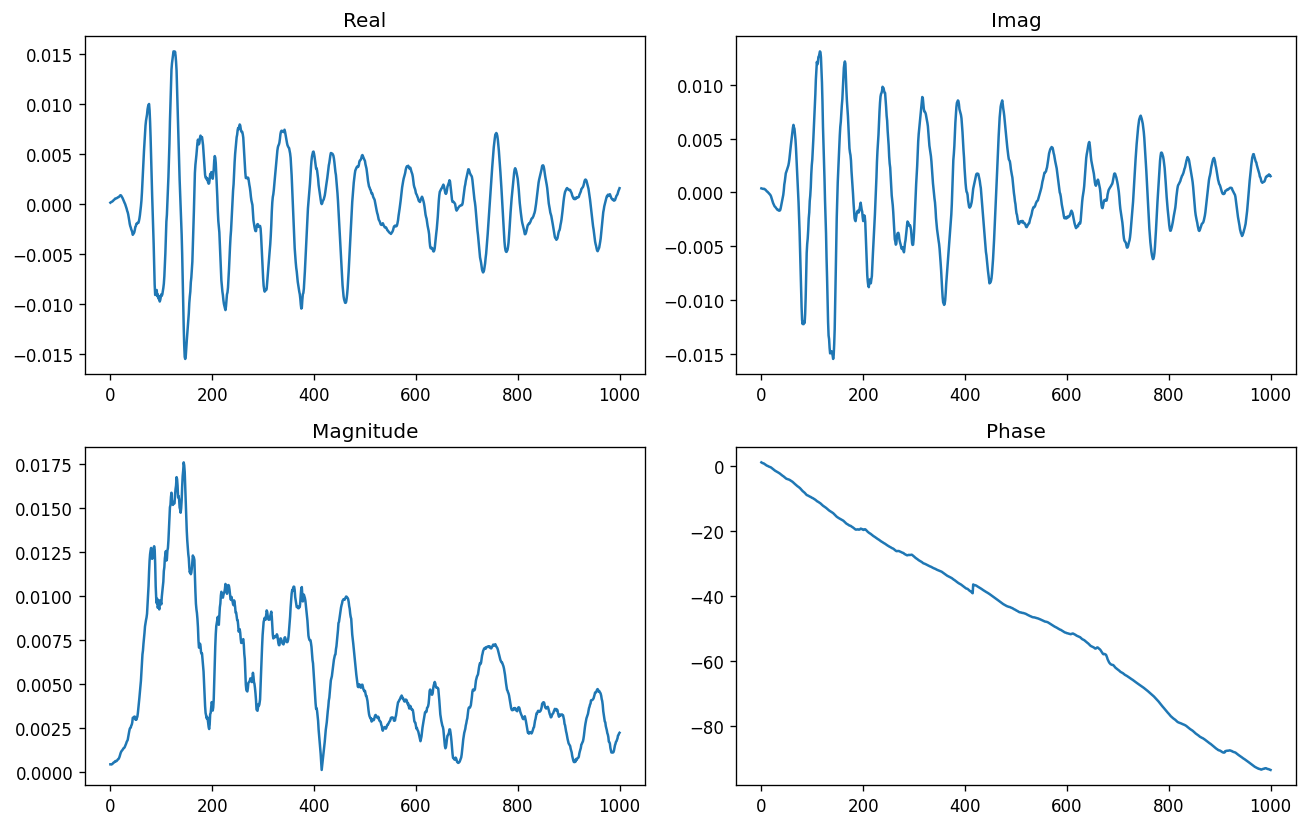

In [7]:
# ============================================================
# Signal Inspection
# ============================================================

scan=0
channel=0

signal=s21[scan,:,channel]

fig,ax=plt.subplots(2,2,figsize=(11,7))

ax[0,0].plot(signal.real)
ax[0,0].set_title("Real")

ax[0,1].plot(signal.imag)
ax[0,1].set_title("Imag")

ax[1,0].plot(np.abs(signal))
ax[1,0].set_title("Magnitude")

ax[1,1].plot(np.unwrap(np.angle(signal)))
ax[1,1].set_title("Phase")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Complex Verification
# ============================================================

print("="*60)

print("Complex Signal Check")

print("="*60)

print("dtype :",signal.dtype)

print("Complex :",np.iscomplexobj(signal))

print()

ifft=np.fft.ifft(signal)

print("IFFT dtype :",ifft.dtype)

print("IFFT Complex :",np.iscomplexobj(ifft))

print()

print("Hilbert Needed ?")

print(
    "NO"
    if np.iscomplexobj(ifft)
    else "YES"
)

Complex Signal Check
dtype : complex128
Complex : True

IFFT dtype : complex128
IFFT Complex : True

Hilbert Needed ?
NO


In [9]:
# ============================================================
# Metadata Statistics
# ============================================================

cols=[
"birads",
"tum_rad",
"tum_in_fib",
"phant_id"
]

display(
    metadata[cols].describe(include="all")
)

,birads,tum_rad,tum_in_fib,phant_id
count,1008.000000,504.000000,490.000000,1301
unique,NaN,NaN,NaN,76
top,NaN,NaN,NaN,
freq,NaN,NaN,NaN,152
mean,2.515873,0.986111,0.183673,NaN
std,1.132593,0.388459,0.387613,NaN
min,1.000000,0.500000,0.000000,NaN
25%,2.000000,0.500000,0.000000,NaN
50%,2.000000,1.000000,0.000000,NaN
75%,4.000000,1.500000,0.000000,NaN


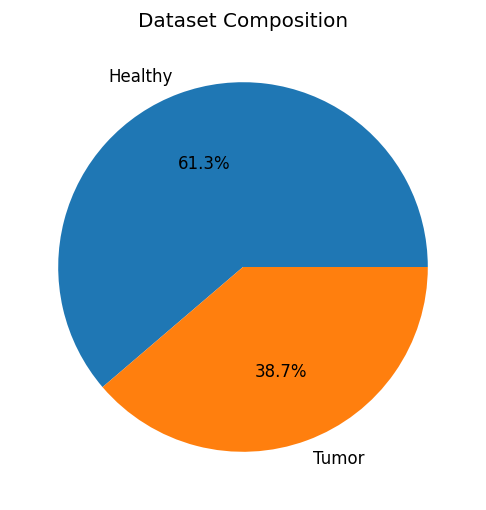

Healthy : 797
Tumor : 504


In [10]:
# ============================================================
# Healthy vs Tumor
# ============================================================

healthy=metadata["tum_rad"].isna().sum()

tumor=len(metadata)-healthy

plt.figure(figsize=(5,5))

plt.pie(
    [healthy,tumor],
    labels=["Healthy","Tumor"],
    autopct="%1.1f%%"
)

plt.title("Dataset Composition")

plt.show()

print("Healthy :",healthy)

print("Tumor :",tumor)

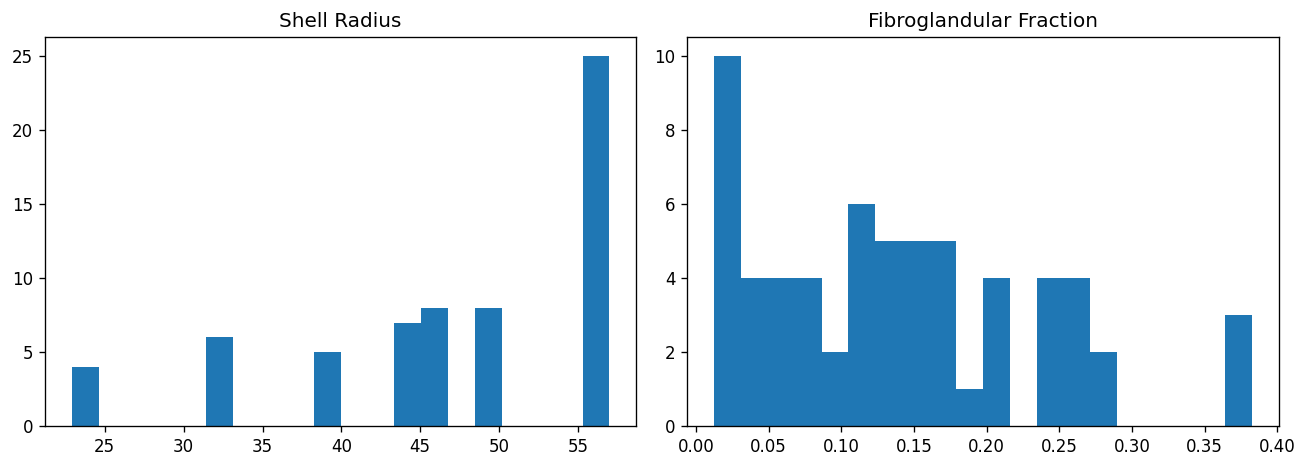

In [11]:
# ============================================================
# Phantom Statistics
# ============================================================

fig,ax=plt.subplots(1,2,figsize=(11,4))

ax[0].hist(
    phantom_db["shell_radius"],
    bins=20
)

ax[0].set_title("Shell Radius")

ax[1].hist(
    phantom_db["fib_percent"],
    bins=20
)

ax[1].set_title("Fibroglandular Fraction")

plt.tight_layout()

plt.show()

In [12]:
# ============================================================
# Search Frequency Files
# ============================================================

print("="*60)
print("Searching Frequency Information")
print("="*60)

for root,dirs,files in os.walk(DATASET_DIR):

    for file in files:

        if "freq" in file.lower():

            print(file)

Searching Frequency Information


In [13]:
# ============================================================
# FINAL REPORT
# ============================================================

print()

print("="*65)

print("UM-BMID DATASET AUDIT")

print("="*65)

print(f"Scans                 : {s21.shape[0]}")

print(f"Frequency Samples     : {s21.shape[1]}")

print(f"Channels              : {s21.shape[2]}")

print()

print(f"Complex Dataset       : {np.iscomplexobj(s21)}")

print(f"Complex Time Signal   : {np.iscomplexobj(np.fft.ifft(s21[0,:,0]))}")

print()

print(f"Hilbert Required      : {'NO' if np.iscomplexobj(np.fft.ifft(s21[0,:,0])) else 'YES'}")

print()

print(f"Healthy Scans         : {healthy}")

print(f"Tumor Scans           : {tumor}")

print()

print(f"Unique Phantoms       : {metadata['phant_id'].nunique()}")

print(f"Merge Success         : {merged['shell_radius'].notna().sum()} / {len(merged)}")

print()

print("Recommended Pipeline")

print("--------------------")

print("TVSVD")

print("→ Complex IFFT")

print("→ Bent-Ray TOF")

print("→ Complex Interpolation")

print("→ Phase-DMAS")

print("→ MER")

print("→ Contrast Refinement")

print("="*65)


UM-BMID DATASET AUDIT
Scans                 : 505
Frequency Samples     : 1001
Channels              : 72

Complex Dataset       : True
Complex Time Signal   : True

Hilbert Required      : NO

Healthy Scans         : 797
Tumor Scans           : 504

Unique Phantoms       : 76
Merge Success         : 976 / 1301

Recommended Pipeline
--------------------
TVSVD
→ Complex IFFT
→ Bent-Ray TOF
→ Complex Interpolation
→ Phase-DMAS
→ MER
→ Contrast Refinement
